# Per-(codon, SS) KDE Bandwidth Selection via Cross-Validation

Selects a separate KDE bandwidth for each (codon, secondary structure) pair by
maximizing cross-validated pseudo log-likelihood on the flat torus.

**Structure:**
1. Config & imports
2. Preprocess dataset (via `PointwiseCodonDistanceAnalyzer`, equivalent to analysis runs)
3. CV function definitions
4. **Pilot section** — serial sweep over a wide sigma grid on a few representative groups
5. **Main CV sweep** — parallel over all (codon, SS) groups with the committed grid
6. Save outputs (`kernel_bandwidths.csv`, score pickle)
7. Plots (σ vs n, CV curves per SS, CV curves for representative groups)

## 1. Config

In [2]:
from pathlib import Path
from math import pi

# ── Paths ───────────────────────────────────────────────────────────────────
DATASET_DIR = Path("../out/prec-collected/20211001_124553-aida-ex_EC-src_EC")
OUT_DIR = Path("../out/pnas-2026/bandwidth_cv")

# ── KDE grid ────────────────────────────────────────────────────────────────
N_BINS = 128
GRID_LOW = -pi
GRID_HIGH = pi

# ── Cross-validation ────────────────────────────────────────────────────────
CV_MODE = "loo"  # "kfold" / "loo"
K_FOLDS = 5
SEED = 42  # seeds fold assignment and any other random operations
N_MIN = 30  # groups with fewer observations are assigned a fallback sigma

# Tolerance for plateau detection: ε = CV_SCORE_TOLERANCE * (max_LL − min_LL).
# σ_cv is the smallest σ whose LL is within ε of the maximum, so that among
# LL-equivalent bandwidths we pick the most sensitive (smallest) one.
CV_SCORE_TOLERANCE = 0.01  # % of the finite LL range

# ── Parallelism ──────────────────────────────────────────────────────────────
N_JOBS = -1  # joblib workers, -1 means all CPUs

# ── Preprocessing cache ──────────────────────────────────────────────────────
# Set True to reload the preprocessed dataset from OUT_DIR without re-running
# the analyzer preprocessing steps.
SKIP_PREPROCESS = False

OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output will be written to: {OUT_DIR.resolve()}")

Output will be written to: /Users/avivr/dev/technion/phd/pp5/out/pnas-2026/bandwidth_cv


## 2. Imports

In [3]:
import contextlib
import functools
import multiprocessing as mp
import pickle
import warnings

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from scipy import stats
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

try:
    from tqdm_joblib import tqdm_joblib
except ImportError:
    warnings.warn(
        "tqdm_joblib not installed — install it for progress bars during parallel CV. "
        "Falling back to no progress bar."
    )

    @contextlib.contextmanager
    def tqdm_joblib(tqdm_object):
        yield tqdm_object


from pp5.analysis.pointwise import (
    AGGREGATION_TYPE_CENTROID,
    CODON_COL,
    CONDITION_COL,
    PHI_COL,
    PSI_COL,
    RANDOMIZE_TYPES_NONE,
    SECONDARY_COL,
    PointwiseCodonDistanceAnalyzer,
)
from pp5.distributions.kde import kde_2d, torus_gaussian_kernel_2d


/Users/avivr/miniforge3/envs/pp5/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


ModuleNotFoundError: No module named 'PyQt5'

Timeline Error: pmg_qt


## 3. Preprocess Dataset

Preprocessing is performed by instantiating `PointwiseCodonDistanceAnalyzer` with the
same config used in `scripts/analyze_pointwise.py`, then calling its `_preprocess_dataset`
method. This ensures exact equivalence with the statistical test pipeline:
- Rows with missing SS, `unp_idx`, or ambiguous codons (`codon_score < 1.0`) are dropped.
- DSSP codes are consolidated to HELIX / SHEET / TURN / OTHER via `DSSP_TO_SS_TYPE`.
- Redundant copies of the same residue across PDB entries are aggregated by centroid angle on the flat torus.

The result is cached to `OUT_DIR/dataset_preprocessed.pkl`. Set `SKIP_PREPROCESS = True` to reload the cache.

In [4]:
PREPROCESS_CACHE = OUT_DIR / "dataset_preprocessed.pkl"

if SKIP_PREPROCESS and PREPROCESS_CACHE.is_file():
    print(f"Loading preprocessed dataset from cache: {PREPROCESS_CACHE}")
    df = pd.read_pickle(PREPROCESS_CACHE)
else:
    print("Running preprocessing via PointwiseCodonDistanceAnalyzer...")

    # Instantiate the analyzer with the Brief-Report config (matching analyze_pointwise.py)
    analyzer = PointwiseCodonDistanceAnalyzer(
        dataset_dir=DATASET_DIR,
        out_dir=OUT_DIR,
        out_tag="bw_cv_preprocess",
        aggregation_type=AGGREGATION_TYPE_CENTROID,
        aggregation_min_group_size=1,
        strict_codons=True,
        condition_on_ss=True,
        ignore_omega=True,
        tuple_len=1,
        randomize_codons=RANDOMIZE_TYPES_NONE,
        # These are only needed for the statistical test, not preprocessing:
        ddist_statistic="kde_g",
        ddist_k=0,
    )

    # Run only the preprocessing step. Workers use the spawn context so that
    # pp5 module-level functions can be pickled safely.
    n_workers = N_JOBS if N_JOBS > 0 else mp.cpu_count()
    mp_ctx = mp.get_context("spawn")
    with mp_ctx.Pool(n_workers) as pool:
        analyzer._preprocess_dataset(pool)

    df = analyzer._load_intermediate("dataset")
    df.to_pickle(PREPROCESS_CACHE)
    print(f"Preprocessed dataset cached to: {PREPROCESS_CACHE}")

print(f"Dataset: {len(df):,} aggregated residues, columns: {list(df.columns)}")
df.head()

Running preprocessing via PointwiseCodonDistanceAnalyzer...


/Users/avivr/dev/technion/phd/pp5/src/pp5/analysis/pointwise.py:651: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pointwise[CODON_COL] = df_pointwise[[CODON_COL]].applymap(codon2aac)
/Users/avivr/miniforge3/envs/pp5/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/Users/avivr/miniforge3/envs/pp5/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to 

Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
Timeline Error: pmg_qt
[2026-04-24 12:45:54,009 pp5.analysis.pointwise]    INFO >> preprocessing done, elapsed=12.74s
[2026-04-24 12:45:54,013 pp5.analysis.pointwise]    INFO >>             unp_id  unp_idx AA  codon condition_group secondary         phi  \
0       A0A024FRL9      257  A  A-GCA           HELIX     HELIX  -62.900004   
1       A0A024L327      223  A  A-GCA           HELIX     HELIX  -60.749997   
2       A0A024L327      226  A  A-GCA           HELIX     HELIX  -62.830002   
3       A0A024L327      289  A  A-GCA           HELIX     HELIX  -67.179999   
4       A0A024L327      387  A  A-GCA           HELIX     HELIX  -60.790002   
...            ...      ... ..    ...            

,unp_id,unp_idx,AA,codon,condition_group,secondary,phi,psi,omega,group_size,group_std
76581,A0A024FRL9,43,Q,Q-CAA,SHEET,SHEET,-86.129997,111.519996,NaN,1,0.0
78084,A0A024FRL9,44,R,R-CGG,SHEET,SHEET,-101.529997,126.879998,NaN,1,0.0
65217,A0A024FRL9,45,F,F-TTT,SHEET,SHEET,-136.850012,116.059995,NaN,1,0.0
91127,A0A024FRL9,46,G,G-GGC,TURN,TURN,56.680000,-130.770010,NaN,1,0.0
88833,A0A024FRL9,47,D,D-GAT,TURN,TURN,-97.879999,8.350000,NaN,1,0.0


In [5]:
# Group sizes per (codon, SS)
group_sizes = (
    df.groupby([CODON_COL, CONDITION_COL])
    .size()
    .reset_index(name="n")
    .rename(columns={CONDITION_COL: "ss", CODON_COL: "codon"})
)
print(f"Total (codon, SS) groups: {len(group_sizes)}")
print(f"Groups with n >= {N_MIN=}: {(group_sizes['n'] >= N_MIN).sum()}")
print(f"\nGroup size summary:")
group_sizes["n"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

Total (codon, SS) groups: 244
Groups with n >= N_MIN=30: 238

Group size summary:


count     244.000000
mean      415.651639
std       408.036165
min         8.000000
10%        84.300000
25%       152.500000
50%       288.500000
75%       545.500000
90%       882.600000
max      2812.000000
Name: n, dtype: float64

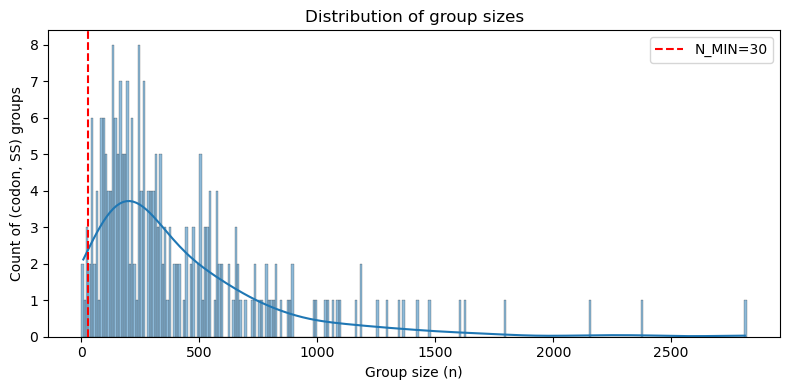

In [6]:
# plot histogram of group sizes
plt.figure(figsize=(8, 4))
sns.histplot(
    group_sizes["n"],
    # bins=np.logspace(
    #     np.log10(1),
    #     np.log10(group_sizes["n"].max()),
    #     20,
    # ),
    # bins=np.linspace(0, group_sizes["n"].max(), 20),
    bins=np.arange(0, group_sizes["n"].max() + 10, 10),
    kde=True,
    cumulative=False,
)
plt.axvline(N_MIN, color="red", linestyle="--", label=f"N_MIN={N_MIN}")
# plt.xlim(0, 500)
plt.xlabel("Group size (n)")
plt.ylabel("Count of (codon, SS) groups")
plt.title("Distribution of group sizes")
plt.legend()
plt.tight_layout()


In [7]:
print(group_sizes.sort_values("n", ascending=True).head(10))

     codon     ss   n
159  R-AGG   TURN   8
157  R-AGG  OTHER   9
75   I-ATA   TURN  13
95   L-CTA   TURN  21
155  R-AGA   TURN  25
158  R-AGG  SHEET  27
93   L-CTA  OTHER  32
23   C-TGT   TURN  39
219  V-GTA   TURN  40
161  R-CGA  OTHER  44


## 4. CV Functions


In [8]:
# CV helpers live in pp5 so the pipeline and this notebook share one implementation.
# See src/pp5/distributions/bandwidth_cv.py.
from pp5.distributions.bandwidth_cv import (
    compute_kernel_slabs,
    compute_observation_bin_indices,
    cross_validate_log_likelihood_loo,
    cross_validate_log_likelihood_kfold,
    cross_validate_bandwidths_for_group,
)

## 5. Pilot Section

Runs CV on a handful of representative groups over a **very wide** sigma grid.
Inspect the CV curves to decide where the optima lie, then commit to a narrower
grid in Section 6 before running the full parallel sweep.

Runtime: seconds (3 groups × 30 sigma values, serial).

In [9]:
# Wide pilot grid: 0.25° to 128°, 30 log-spaced points
PILOT_SIGMA_GRID_DEG = np.logspace(np.log10(0.1), np.log10(128), 100)
PILOT_SIGMA_GRID_RAD = np.deg2rad(PILOT_SIGMA_GRID_DEG)

# Select pilot groups: smallest-N, median-N, largest-N among groups with n >= N_MIN
eligible = group_sizes[group_sizes["n"] >= N_MIN].copy().reset_index(drop=True)
sorted_n = eligible["n"].sort_values()
pilot_indices = [
    sorted_n.index[0],  # smallest N above N_MIN
    sorted_n.index[len(sorted_n) // 2],  # median N
    sorted_n.index[-1],  # largest N
]
pilot_groups = eligible.loc[pilot_indices]
print("Pilot groups:")
print(pilot_groups[["codon", "ss", "n"]].to_string(index=False))

Pilot groups:
codon    ss    n
L-CTA OTHER   32
L-CTT SHEET  297
L-CTG HELIX 2812


In [10]:
# Build a lookup from (codon, ss) -> (phi_rad, psi_rad)
def get_group_angles(codon, ss):
    mask = (df[CODON_COL] == codon) & (df[CONDITION_COL] == ss)
    sub = df[mask]
    return np.deg2rad(sub[PHI_COL].values), np.deg2rad(sub[PSI_COL].values)


pilot_results = []
for _, row in tqdm(pilot_groups.iterrows(), total=len(pilot_groups), desc="Pilot CV"):
    phi_rad, psi_rad = get_group_angles(row["codon"], row["ss"])
    result = cross_validate_bandwidths_for_group(
        group_key=(row["codon"], row["ss"]),
        phi_rad=phi_rad,
        psi_rad=psi_rad,
        sigma_grid_rad=PILOT_SIGMA_GRID_RAD,
        cv_mode=CV_MODE,
        n_folds=K_FOLDS,
        n_bins=N_BINS,
        grid_low=GRID_LOW,
        grid_high=GRID_HIGH,
        seed=SEED,
        score_tolerance=CV_SCORE_TOLERANCE,
    )
    pilot_results.append(result)
    sigma_cv_deg = np.rad2deg(result["sigma_cv_rad"])
    print(
        f"  {result['codon']:>8} / {result['ss']:<6}  "
        f"n={result['n']:>5}  σ_cv = {sigma_cv_deg:.2f}°"
    )

Pilot CV:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/avivr/dev/technion/phd/pp5/src/pp5/distributions/kde.py:82: RuntimeWarning: invalid value encountered in divide
  K /= np.sum(K, axis=(0, 1)).reshape((1, 1, -1))


     L-CTA / OTHER   n=   32  σ_cv = 21.02°
     L-CTT / SHEET   n=  297  σ_cv = 1.94°
     L-CTG / HELIX   n= 2812  σ_cv = 5.72°


In [11]:
def cv_label() -> str:
    """Short CV mode description for plot titles."""
    if CV_MODE == "loo":
        return "CV=LOO"
    elif CV_MODE == "kfold":
        return f"CV=K-Fold (K={K_FOLDS})"
    else:
        raise ValueError(f"Invalid CV_MODE: {CV_MODE}")


def normalize_scores_for_plot(scores: np.ndarray) -> np.ndarray:
    """Normalize CV scores to [0, 1] for plotting, handling -inf gracefully.

    Scores of -inf arise at very small bandwidths where no other observation
    lands in the held-out bin — mathematically correct, but unusable for
    normalization. Those points are mapped to 0 (worst visible score) so the
    curve drops to the bottom rather than producing NaN gaps.
    """
    finite_scores = np.where(np.isfinite(scores), scores, np.nan)
    score_min = np.nanmin(finite_scores)
    score_max = np.nanmax(finite_scores)
    if not np.isfinite(score_max) or score_max == score_min:
        return np.zeros_like(scores, dtype=float)
    normalized = (finite_scores - score_min) / (score_max - score_min)
    return np.nan_to_num(normalized, nan=0.0)  # -inf regions → 0 (worst on scale)

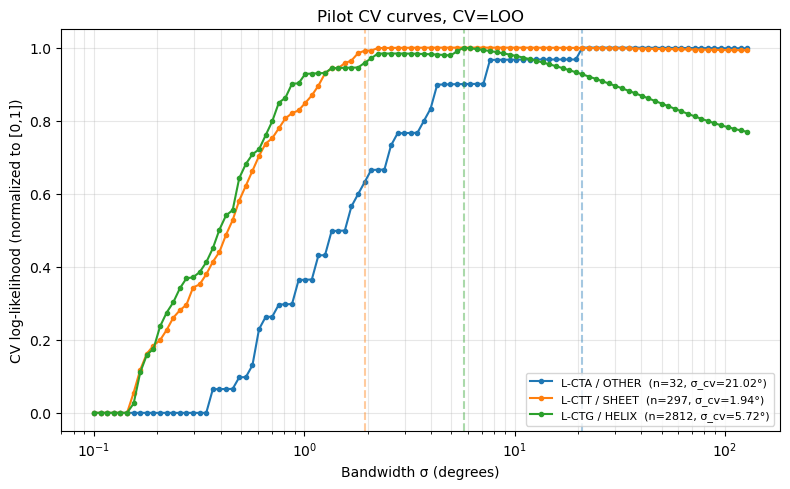


Suggested grid range based on pilot optima:
  Min optimal σ: 1.94°
  Max optimal σ: 21.02°


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

for result in pilot_results:
    sigma_cv_deg = np.rad2deg(result["sigma_cv_rad"])
    label = f"{result['codon']} / {result['ss']}  (n={result['n']}, σ_cv={sigma_cv_deg:.2f}°)"
    sigma_deg = np.rad2deg(result["sigma_grid_rad"])
    scores_norm = normalize_scores_for_plot(result["scores"])
    ax.plot(sigma_deg, scores_norm, marker="o", markersize=3, label=label)
    ax.axvline(sigma_cv_deg, linestyle="--", alpha=0.4, color=ax.lines[-1].get_color())

ax.set_xscale("log")
ax.set_xlabel("Bandwidth σ (degrees)")
ax.set_ylabel("CV log-likelihood (normalized to [0,1])")
ax.set_title(f"Pilot CV curves, {cv_label()}")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "pilot_cv_curves.pdf", bbox_inches="tight")
plt.show()

print("\nSuggested grid range based on pilot optima:")
optimal_sigmas_deg = [np.rad2deg(r["sigma_cv_rad"]) for r in pilot_results]
print(f"  Min optimal σ: {min(optimal_sigmas_deg):.2f}°")
print(f"  Max optimal σ: {max(optimal_sigmas_deg):.2f}°")

## 6. Main CV Sweep

We adjust `SIGMA_GRID_DEG` so that the grid interior covers all pilot optima with a comfortable margin.


In [13]:
# ── Committed sigma grid — update after inspecting pilot results ─────────────
SIGMA_GRID_DEG = np.logspace(np.log10(1), np.log10(32), 100)
SIGMA_GRID_RAD = np.deg2rad(SIGMA_GRID_DEG)

print(f"Committed sigma grid ({len(SIGMA_GRID_DEG)} points):")
print(f"  {SIGMA_GRID_DEG[0]:.3f}° … {SIGMA_GRID_DEG[-1]:.3f}°")

SIGMA_GRID_DEG

Committed sigma grid (100 points):
  1.000° … 32.000°


array([ 1.        ,  1.03562741,  1.07252413,  1.11073538,  1.150308  ,
        1.19129049,  1.23373308,  1.27768779,  1.3232085 ,  1.37035098,
        1.41917304,  1.46973449,  1.52209732,  1.5763257 ,  1.6324861 ,
        1.69064735,  1.75088073,  1.81326007,  1.87786182,  1.94476517,
        2.01405211,  2.08580756,  2.16011948,  2.23707893,  2.31678026,
        2.39932113,  2.48480272,  2.5733298 ,  2.66501086,  2.75995829,
        2.85828845,  2.96012185,  3.06558332,  3.1748021 ,  3.28791207,
        3.40505185,  3.52636502,  3.65200026,  3.78211156,  3.91685839,
        4.0564059 ,  4.20092512,  4.35059319,  4.50559354,  4.66611616,
        4.83235778,  5.00452215,  5.1828203 ,  5.36747075,  5.55869982,
        5.75674188,  5.96183966,  6.17424455,  6.39421687,  6.62202624,
        6.85795186,  7.1022829 ,  7.35531883,  7.61736977,  7.8887569 ,
        8.16981285,  8.4608821 ,  8.76232139,  9.07450018,  9.39780109,
        9.73262037, 10.0793684 , 10.43847016, 10.81036578, 11.19

In [14]:
# Build the list of groups to process
cv_groups = []
for (codon, ss), group_df in df.groupby([CODON_COL, CONDITION_COL]):
    if len(group_df) >= N_MIN:
        phi_rad = np.deg2rad(group_df[PHI_COL].values)
        psi_rad = np.deg2rad(group_df[PSI_COL].values)
        cv_groups.append((codon, ss, phi_rad, psi_rad))

print(f"Running CV on {len(cv_groups)} (codon, SS) groups with n >= {N_MIN}.")
print(
    f"Grid: {len(SIGMA_GRID_DEG)} sigmas * {len(cv_groups)} groups = "
    f"{len(SIGMA_GRID_DEG) * len(cv_groups)} slab computations total."
)

Running CV on 238 (codon, SS) groups with n >= 30.
Grid: 100 sigmas * 238 groups = 23800 slab computations total.


In [15]:
with tqdm_joblib(tqdm(total=len(cv_groups), desc="CV sweep")):
    cv_results_list = Parallel(n_jobs=N_JOBS)(
        delayed(cross_validate_bandwidths_for_group)(
            group_key=(codon, ss),
            phi_rad=phi_rad,
            psi_rad=psi_rad,
            sigma_grid_rad=SIGMA_GRID_RAD,
            cv_mode=CV_MODE,
            n_folds=K_FOLDS,
            n_bins=N_BINS,
            grid_low=GRID_LOW,
            grid_high=GRID_HIGH,
            seed=SEED,
            score_tolerance=CV_SCORE_TOLERANCE,
        )
        for codon, ss, phi_rad, psi_rad in cv_groups
    )


CV sweep:   0%|          | 0/238 [00:00<?, ?it/s]

  0%|          | 0/238 [00:00<?, ?it/s]

/Users/avivr/miniforge3/envs/pp5/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [16]:
# Build summary DataFrame
from numba.cuda.stubs import local

cv_summary_rows = [
    {
        "codon": r["codon"],
        "aa": r["codon"].split("-")[0],
        "ss": r["ss"],
        "n": r["n"],
        "sigma_cv_rad": r["sigma_cv_rad"],
        "sigma_cv_deg": float(np.rad2deg(r["sigma_cv_rad"])),
        "sigma_argmax_deg": float(np.rad2deg(r["sigma_argmax_rad"])),
        "score_at_cv": r["score_at_cv"],
        "is_fallback": False,
    }
    for r in cv_results_list
]

# Fallback: assign SS-median sigma to groups with n < N_MIN
fallback_groups = group_sizes[group_sizes["n"] < N_MIN].copy()
if len(fallback_groups) > 0:
    df_cv = pd.DataFrame(cv_summary_rows)

    df_median_sigma = df_cv.groupby(["ss", "aa"])["sigma_cv_deg"].median().reset_index()

    for _, row in fallback_groups.iterrows():
        aa = row["codon"].split("-")[0]

        # Fallback based on median sigma for the same AA+SS
        fallback_sigma_deg_df = df_median_sigma.query(
            "ss == @ss and aa == @aa",
            local_dict={"ss": row["ss"], "aa": aa},
        )
        assert len(fallback_sigma_deg_df) == 1

        fallback_sigma_deg = fallback_sigma_deg_df["sigma_cv_deg"].values[0]

        cv_summary_rows.append(
            {
                "codon": row["codon"],
                "aa": aa,
                "ss": row["ss"],
                "n": row["n"],
                "sigma_cv_rad": float(np.deg2rad(fallback_sigma_deg)),
                "sigma_cv_deg": float(fallback_sigma_deg),
                "sigma_argmax_deg": float("nan"),
                "score_at_cv": float("nan"),
                "is_fallback": True,
            }
        )
    print(f"Assigned fallback sigma to {len(fallback_groups)} small groups.")

df_cv = (
    pd.DataFrame(cv_summary_rows).sort_values(["ss", "codon"]).reset_index(drop=True)
)
print(f"Summary DataFrame: {len(df_cv)} rows")
df_cv.head(10)

Assigned fallback sigma to 6 small groups.
Summary DataFrame: 244 rows


,codon,aa,ss,n,sigma_cv_rad,sigma_cv_deg,sigma_argmax_deg,score_at_cv,is_fallback
0,A-GCA,A,HELIX,1258,0.031647,1.813260,2.484803,-5302.004526,False
1,A-GCC,A,HELIX,1607,0.084341,4.832358,4.832358,-7804.782202,False
2,A-GCG,A,HELIX,2157,0.090457,5.182820,5.182820,-10288.294083,False
3,A-GCT,A,HELIX,994,0.090457,5.182820,5.182820,-4442.798483,False
4,C-TGC,C,HELIX,193,0.100474,5.756742,5.756742,-940.174035,False
5,C-TGT,C,HELIX,167,0.070798,4.056406,4.505594,-773.518474,False
6,D-GAC,D,HELIX,805,0.132948,7.617370,7.617370,-3947.671439,False
7,D-GAT,D,HELIX,1347,0.061547,3.526365,3.526365,-6809.870294,False
8,E-GAA,E,HELIX,2374,0.039044,2.237079,2.858288,-11419.490508,False
9,E-GAG,E,HELIX,1161,0.049887,2.858288,2.960122,-5167.781566,False


In [17]:
# Example with fallback
df_cv.query("ss == 'OTHER' and aa == 'R'").sort_values("sigma_cv_deg")[
    ["codon", "ss", "n", "sigma_cv_deg", "is_fallback"]
]

,codon,ss,n,sigma_cv_deg,is_fallback
101,R-CGA,OTHER,44,6.857952,False
103,R-CGG,OTHER,53,7.888757,False
100,R-AGG,OTHER,9,12.007456,True
104,R-CGT,OTHER,344,12.007456,False
99,R-AGA,OTHER,48,12.878286,False
102,R-CGC,OTHER,377,17.647772,False


## 7. Save Outputs

In [18]:
# Save summary CSV
bandwidths_csv_path = OUT_DIR / "kernel_bandwidths.csv"
df_cv.to_csv(bandwidths_csv_path, index=False)
print(f"Saved: {bandwidths_csv_path}")

# Save full score arrays (needed for CV curve plots)
scores_pkl_path = OUT_DIR / "kernel_bandwidth_cv_scores.pkl"
with open(scores_pkl_path, "wb") as f:
    pickle.dump(
        {
            "sigma_grid_rad": SIGMA_GRID_RAD,
            "sigma_grid_deg": SIGMA_GRID_DEG,
            "cv_mode": CV_MODE,
            "k_folds": K_FOLDS,
            "seed": SEED,
            "results": cv_results_list,
        },
        f,
        protocol=4,
    )
print(f"Saved: {scores_pkl_path}")

Saved: ../out/pnas-2026/bandwidth_cv/kernel_bandwidths.csv
Saved: ../out/pnas-2026/bandwidth_cv/kernel_bandwidth_cv_scores.pkl


## 8. Plots


In [19]:
# Colors for SS classes (consistent across all plots)
SS_CLASSES = ["HELIX", "SHEET", "TURN", "OTHER"]
SS_COLORS = dict(zip(SS_CLASSES, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))

# Map results to a lookup dict for convenient access
cv_results_lookup = {(r["codon"], r["ss"]): r for r in cv_results_list}

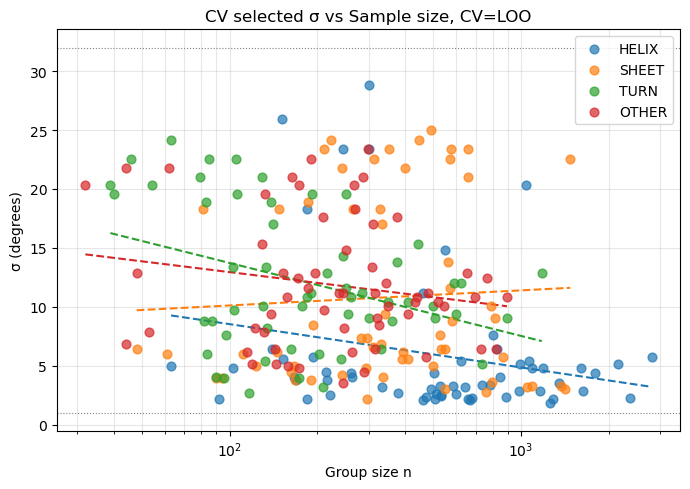

Saved sigma_vs_n.pdf


In [20]:
# ── Plot 1: σ_cv vs n scatter with per-SS linear regression ─────────────────

df_plot = df_cv[~df_cv["is_fallback"]].copy()

fig, ax = plt.subplots(figsize=(7, 5))
for ss in SS_CLASSES:
    sub = df_plot[df_plot["ss"] == ss]
    ax.scatter(
        sub["n"],
        sub["sigma_cv_deg"],
        label=ss,
        color=SS_COLORS[ss],
        alpha=0.7,
        s=40,
        zorder=3,
    )
    # Linear regression of sigma_cv_deg on log10(n)
    if len(sub) >= 2:
        log_n = np.log10(sub["n"].values)
        slope, intercept, *_ = stats.linregress(log_n, sub["sigma_cv_deg"].values)
        n_range = np.linspace(log_n.min(), log_n.max(), 200)
        ax.plot(
            10**n_range,
            intercept + slope * n_range,
            color=SS_COLORS[ss],
            linewidth=1.5,
            linestyle="--",
            zorder=2,
        )

ax.set_xscale("log")
ax.set_xlabel("Group size n")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"CV selected σ vs Sample size, {cv_label()}")
ax.legend(loc="upper right")
ax.grid(True, which="both", alpha=0.3)

# Mark grid boundaries
ax.axhline(SIGMA_GRID_DEG[0], color="gray", linestyle=":", linewidth=0.8)
ax.axhline(SIGMA_GRID_DEG[-1], color="gray", linestyle=":", linewidth=0.8)

plt.tight_layout()
fig.savefig(PLOTS_DIR / "sigma_vs_n.pdf", bbox_inches="tight")
plt.show()
print("Saved sigma_vs_n.pdf")

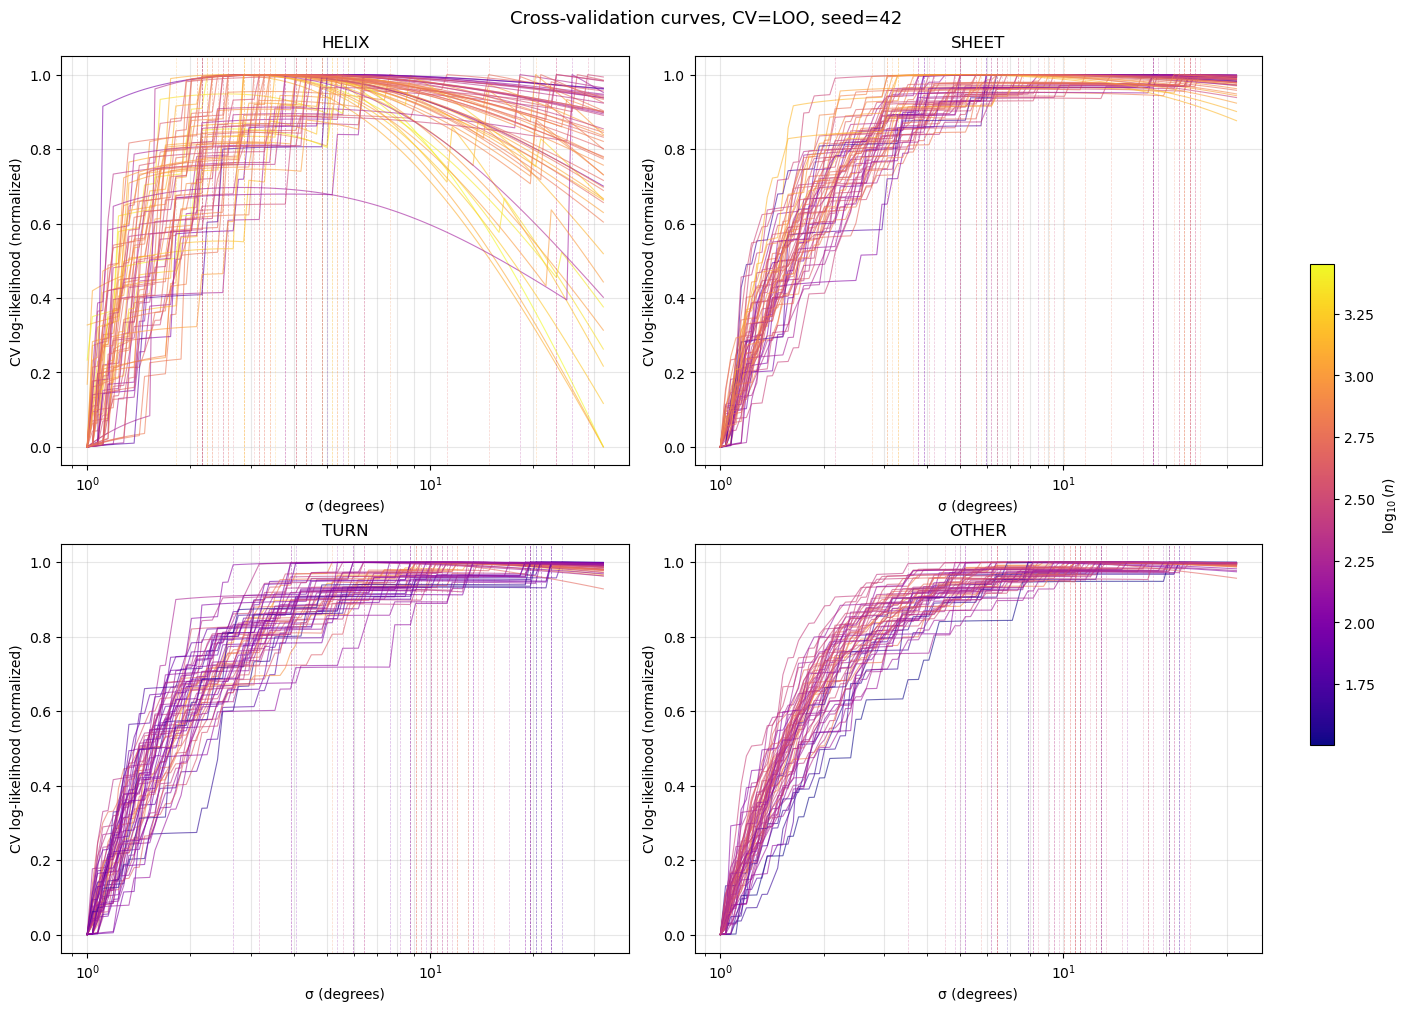

Saved cv_curves_by_ss.pdf


In [21]:
# ── Plot 2: CV curves faceted by SS class ───────────────────────────────────
# One panel per SS class; each codon is a line colored by log(n).
# constrained_layout=True handles colorbar spacing automatically.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False, constrained_layout=True)
axes = axes.flatten()

log_n_all = [np.log10(r["n"]) for r in cv_results_list]
log_n_min, log_n_max = min(log_n_all), max(log_n_all)
norm = mcolors.Normalize(vmin=log_n_min, vmax=log_n_max)
cmap = plt.get_cmap("plasma")

for ax_idx, ss in enumerate(SS_CLASSES):
    ax = axes[ax_idx]
    ss_results = [r for r in cv_results_list if r["ss"] == ss]

    for result in ss_results:
        color = cmap(norm(np.log10(result["n"])))
        scores_norm = normalize_scores_for_plot(result["scores"])
        ax.plot(SIGMA_GRID_DEG, scores_norm, color=color, alpha=0.6, linewidth=0.8)
        ax.axvline(
            np.rad2deg(result["sigma_cv_rad"]),
            color=color,
            alpha=0.3,
            linewidth=0.5,
            linestyle="--",
        )

    ax.set_xscale("log")
    ax.set_title(ss)
    ax.set_xlabel("σ (degrees)")
    ax.set_ylabel("CV log-likelihood (normalized)")
    ax.grid(True, which="both", alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=list(axes), fraction=0.02, pad=0.04)
cbar.set_label(r"$\log_{10}(n)$")

fig.suptitle(f"Cross-validation curves, {cv_label()}, seed={SEED}", fontsize=13)
fig.savefig(PLOTS_DIR / "cv_curves_by_ss.pdf", bbox_inches="tight")
plt.show()
print("Saved cv_curves_by_ss.pdf")

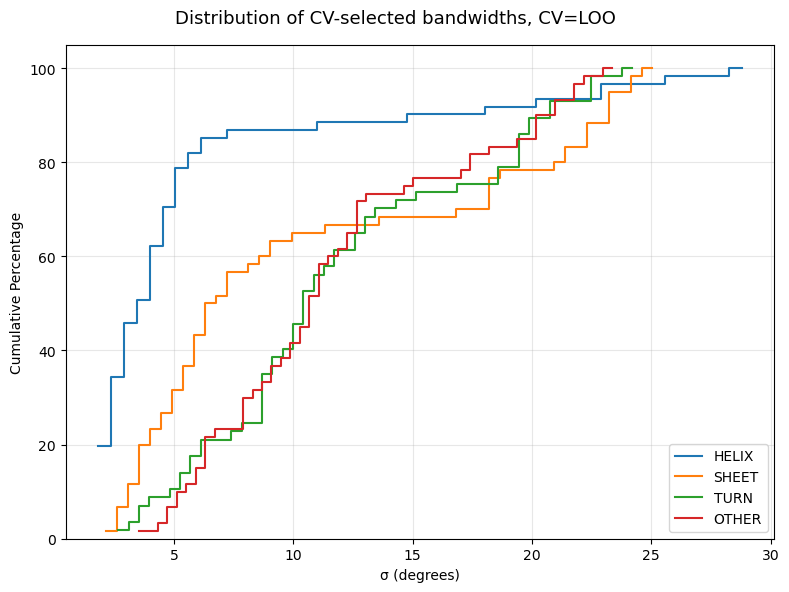

Saved sigma_distribution_by_ss.pdf


In [22]:
# ── Plot 2b: Distribution of selected σ values per SS class ─────────────────

fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharey=False)
# axes = axes.flatten()

for ax_idx, ss in enumerate(SS_CLASSES):
    # ax = axes[ax_idx]
    sub = df_cv[(df_cv["ss"] == ss) & ~df_cv["is_fallback"]]
    sns.histplot(
        data=sub,
        x="sigma_cv_deg",
        kde=False,
        stat="percent",
        cumulative=True,
        color=SS_COLORS[ss],
        ax=ax,
        bins=50,
        element="step",
        fill=False,
        label=ss,
    )
    ax.set_xlabel("σ (degrees)")
    ax.set_ylabel("Cumulative Percentage")
    ax.grid(True, alpha=0.3)

ax.legend(loc="lower right")
fig.suptitle(f"Distribution of CV-selected bandwidths, {cv_label()}", fontsize=13)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "sigma_distribution_by_ss.pdf", bbox_inches="tight")
plt.show()
print("Saved sigma_distribution_by_ss.pdf")

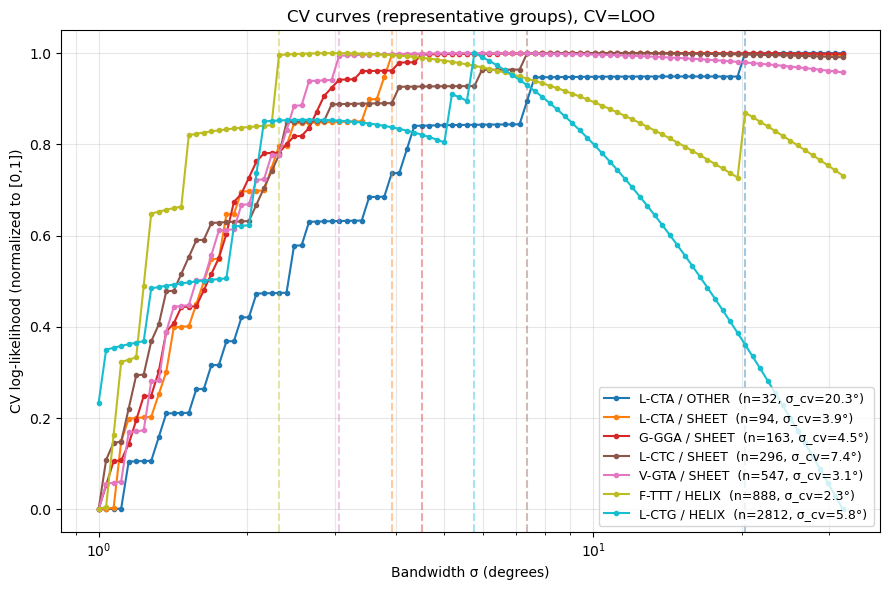

Saved cv_curves_representative.pdf


In [23]:
# ── Plot 3: CV curves for representative groups (committed grid) ─────────────
# Groups are selected at specific percentiles of the sample size distribution.
SAMPLE_SIZE_PERCENTILES = [0, 10, 25, 50, 75, 90, 100]

eligible_sorted = eligible.sort_values("n").reset_index(drop=True)
percentile_indices = sorted(
    {
        int(np.round(np.percentile(np.arange(len(eligible_sorted)), p)))
        for p in SAMPLE_SIZE_PERCENTILES
    }
)
rep_groups = eligible_sorted.iloc[percentile_indices]

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(rep_groups)))

for (_, row), color in zip(rep_groups.iterrows(), colors):
    key = (row["codon"], row["ss"])
    if key not in cv_results_lookup:
        continue
    result = cv_results_lookup[key]
    scores_norm = normalize_scores_for_plot(result["scores"])
    sigma_cv_deg = np.rad2deg(result["sigma_cv_rad"])
    label = f"{row['codon']} / {row['ss']}  (n={row['n']}, σ_cv={sigma_cv_deg:.1f}°)"
    ax.plot(
        SIGMA_GRID_DEG, scores_norm, marker="o", markersize=3, label=label, color=color
    )
    ax.axvline(sigma_cv_deg, linestyle="--", alpha=0.4, color=color)

ax.set_xscale("log")
ax.set_xlabel("Bandwidth σ (degrees)")
ax.set_ylabel("CV log-likelihood (normalized to [0,1])")
ax.set_title(f"CV curves (representative groups), {cv_label()}")
ax.legend(loc="lower right", fontsize=9, ncol=1)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "cv_curves_representative.pdf", bbox_inches="tight")
plt.show()
print("Saved cv_curves_representative.pdf")

In [24]:
# ── Sanity check: are any optima at the grid edges? ──────────────────────────
df_non_fallback = df_cv[~df_cv["is_fallback"]]
at_lower_edge = df_non_fallback["sigma_cv_deg"] <= SIGMA_GRID_DEG[0] * 1.05
at_upper_edge = df_non_fallback["sigma_cv_deg"] >= SIGMA_GRID_DEG[-1] * 0.95

if at_lower_edge.any():
    print(f"WARNING: {at_lower_edge.sum()} groups have σ_cv at the lower grid edge.")
    print("Consider extending the grid to smaller values.")
    print(df_non_fallback[at_lower_edge][["codon", "ss", "n", "sigma_cv_deg"]])

if at_upper_edge.any():
    print(f"WARNING: {at_upper_edge.sum()} groups have σ_cv at the upper grid edge.")
    print("Consider extending the grid to larger values.")
    print(df_non_fallback[at_upper_edge][["codon", "ss", "n", "sigma_cv_deg"]])

if not at_lower_edge.any() and not at_upper_edge.any():
    print("All CV optima are in the interior of the committed grid.")

print(f"\nFinal bandwidth summary:")
print(
    df_cv.groupby("ss")["sigma_cv_deg"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .round(2)
)

All CV optima are in the interior of the committed grid.

Final bandwidth summary:
       count   mean   std   min   10%   25%    50%    75%    90%    max
ss                                                                     
HELIX   61.0   5.94  6.27  1.81  2.16  2.57   3.78   5.37  14.81  28.81
OTHER   61.0  11.87  5.35  3.53  5.76  7.89  10.81  14.81  20.30  23.35
SHEET   61.0  10.92  7.74  2.16  3.29  4.83   6.86  18.28  23.35  25.05
TURN    61.0  12.12  5.74  2.67  5.37  8.76  10.81  15.95  20.30  24.18


## Ramachandran plots

In [48]:
from pp5.codons import AA_CODONS
from pp5.plot import ramachandran as _ramachandran


def _get_group_angles_rad(codon: str, ss: str) -> np.ndarray:
    mask = (df[CODON_COL] == codon) & (df[CONDITION_COL] == ss)
    return np.deg2rad(df.loc[mask, [PHI_COL, PSI_COL]].to_numpy(dtype=float))


def _get_group_sigma_rad(
    codon: str, ss: str, fixed_sigma_deg: float | None = None
) -> float | None:
    if fixed_sigma_deg is not None:
        return float(np.deg2rad(fixed_sigma_deg))

    match = df_cv[(df_cv["codon"] == codon) & (df_cv["ss"] == ss)]
    if match.empty:
        return None

    sigma_rad = float(match.iloc[0]["sigma_cv_rad"])
    return sigma_rad if np.isfinite(sigma_rad) else None


def _estimate_group_kde(phi_psi_rad: np.ndarray, sigma_rad: float) -> np.ndarray | None:
    if phi_psi_rad.size == 0 or sigma_rad is None or not np.isfinite(sigma_rad):
        return None

    slabs = compute_kernel_slabs(
        phi_rad=phi_psi_rad[:, 0],
        psi_rad=phi_psi_rad[:, 1],
        sigma_rad=sigma_rad,
        n_bins=N_BINS,
        grid_low=GRID_LOW,
        grid_high=GRID_HIGH,
    )
    kde = slabs.sum(axis=2)
    kde_sum = kde.sum()
    if not np.isfinite(kde_sum) or kde_sum <= 0:
        return None
    return kde / kde_sum


def _format_sigma_title(
    codon: str,
    n_obs: int,
    sigma_rad: float | None,
    fixed_sigma_deg: float | None = None,
) -> str:
    if fixed_sigma_deg is not None:
        return f"{codon} (n={n_obs})"
    if sigma_rad is None or not np.isfinite(sigma_rad):
        return f"{codon} (n={n_obs}, $\\sigma$=n/a)"
    return f"{codon} (n={n_obs}, $\\sigma$={np.rad2deg(sigma_rad):.1f}°)"


def _format_rama_axis(ax: plt.Axes, row_idx: int, col_idx: int, title: str) -> None:
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.5)

    if row_idx < 7:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    if col_idx > 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()


def _plot_codon_ramachandran_grid(
    ss: str, fixed_sigma_deg: float | None = None
) -> plt.Figure:
    fig, axes = plt.subplots(8, 8, figsize=(24, 24), constrained_layout=True)
    axes_flat = axes.ravel()
    sigma_label = (
        f"using fixed $\\sigma$={fixed_sigma_deg:.2f}°"
        if fixed_sigma_deg is not None
        else "using cross-validated bandwidths"
    )

    for idx, codon in enumerate(AA_CODONS):
        row_idx, col_idx = divmod(idx, 8)
        ax = axes_flat[idx]
        phi_psi_rad = _get_group_angles_rad(codon, ss)
        sigma_rad = _get_group_sigma_rad(codon, ss, fixed_sigma_deg=fixed_sigma_deg)
        kde = _estimate_group_kde(phi_psi_rad, sigma_rad)
        n_obs = len(phi_psi_rad)
        title = _format_sigma_title(
            codon,
            n_obs=n_obs,
            sigma_rad=sigma_rad,
            fixed_sigma_deg=fixed_sigma_deg,
        )

        if kde is None:
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=9,
            )
            ax.grid(True, alpha=0.25)
        else:
            _ramachandran(
                pdist=kde,
                legend_label=codon,
                title=None,
                grid_2pi=False,
                ax=ax,
                vmin=0.0,
                vmax=5e-4,  # 5e-4,
                # shading="nearest",
            )

        _format_rama_axis(ax, row_idx=row_idx, col_idx=col_idx, title=title)

    for idx in range(len(AA_CODONS), len(axes_flat)):
        axes_flat[idx].axis("off")

    fig.suptitle(f"Ramachandran KDE per codon, SS={ss}, {sigma_label}", fontsize=18)
    return fig

In [ ]:
FIXED_RAMACHANDRAN_SIGMA_DEG = (
    # None  # Set to a float in degrees to override CV bandwidths.
    10.0
)

ramachandran_grid_figures = {}
for ss in SS_CLASSES:
    fig = _plot_codon_ramachandran_grid(
        ss=ss,
        fixed_sigma_deg=FIXED_RAMACHANDRAN_SIGMA_DEG,
    )
    ramachandran_grid_figures[ss] = fig

    sigma_tag = (
        f"fixed-{FIXED_RAMACHANDRAN_SIGMA_DEG:.2f}deg"
        if FIXED_RAMACHANDRAN_SIGMA_DEG is not None
        else "cv"
    )
    outfile = PLOTS_DIR / f"ramachandran-{ss.lower()}-{sigma_tag}.pdf"
    fig.savefig(outfile, bbox_inches="tight", dpi=300)
    print(f"Saved: {outfile}")
    plt.show()